# **Homework \#4**
### Author: Skyler Ruiter
### Date: December 2, 2025
### Course: Deep Learning Systems (ENGR-E 533)

---

# Setup:

Load the needed modules and setup the device for computation.

In [89]:
import torch
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torchvision
import numpy as np
import time
import matplotlib.pyplot as plt
import librosa
import soundfile as sf
from IPython.display import Audio, display

print(torch.cuda.is_available())
device=torch.device('cuda')
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(device)

True
cuda


In [90]:
mnist_train = torchvision.datasets.MNIST('mnist',
                                         train=True,
                                         download=True,
                                         transform=torchvision.transforms.Compose([
                                             torchvision.transforms.ToTensor(),
                                             torchvision.transforms.Normalize((0.1307,), (0.3081,))
                                         ]))
mnist_test = torchvision.datasets.MNIST('mnist',
                                        train=False,
                                        download=True,
                                        transform=torchvision.transforms.Compose([
                                            torchvision.transforms.ToTensor(),
                                            torchvision.transforms.Normalize((0.1307,), (0.3081,))
                                        ]))

X_train, y_train = mnist_train.data, mnist_train.targets
X_test, y_test = mnist_test.data, mnist_test.targets

X_train = X_train.float()
X_test = X_test.float()

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = (X_train - 0.1307) / 0.3081
X_test = (X_test - 0.1307) / 0.3081

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

train_dataloader = DataLoader(mnist_train, batch_size=100, num_workers=4, pin_memory=True, shuffle=True)
test_dataloader = DataLoader(mnist_test, batch_size=100, num_workers=4, pin_memory=True, shuffle=True)

print(f"Training data shape: {X_train.shape}, {y_train.shape}")
print(f"Test data shape: {X_test.shape}, {y_test.shape}")

Training data shape: torch.Size([60000, 28, 28]), torch.Size([60000])
Test data shape: torch.Size([10000, 28, 28]), torch.Size([10000])


# Problem 1: RNNs as a generative model

Preparing the data

In [91]:
def prepare_patches(images):
    N = images.shape[0]
    sequences = torch.zeros(N, 16, 49, device=images.device)
    patch_idx = 0
    for row in range(4):
      for col in range(4):
        patch = images[:, row*7:(row+1)*7, col*7:(col+1)*7]
        sequences[:, patch_idx, :] = patch.reshape(N, 49)
        patch_idx += 1
    return sequences

In [92]:
X_train_seq = prepare_patches(X_train)
X_test_seq = prepare_patches(X_test)

In [93]:
batch_size = 100
train_loader = DataLoader(X_train_seq, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(X_test_seq, batch_size=batch_size, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")
print(f"Each batch shape: (batch_size={batch_size}, seq_len=16, features=49)")

Number of training batches: 600
Number of test batches: 100
Each batch shape: (batch_size=100, seq_len=16, features=49)


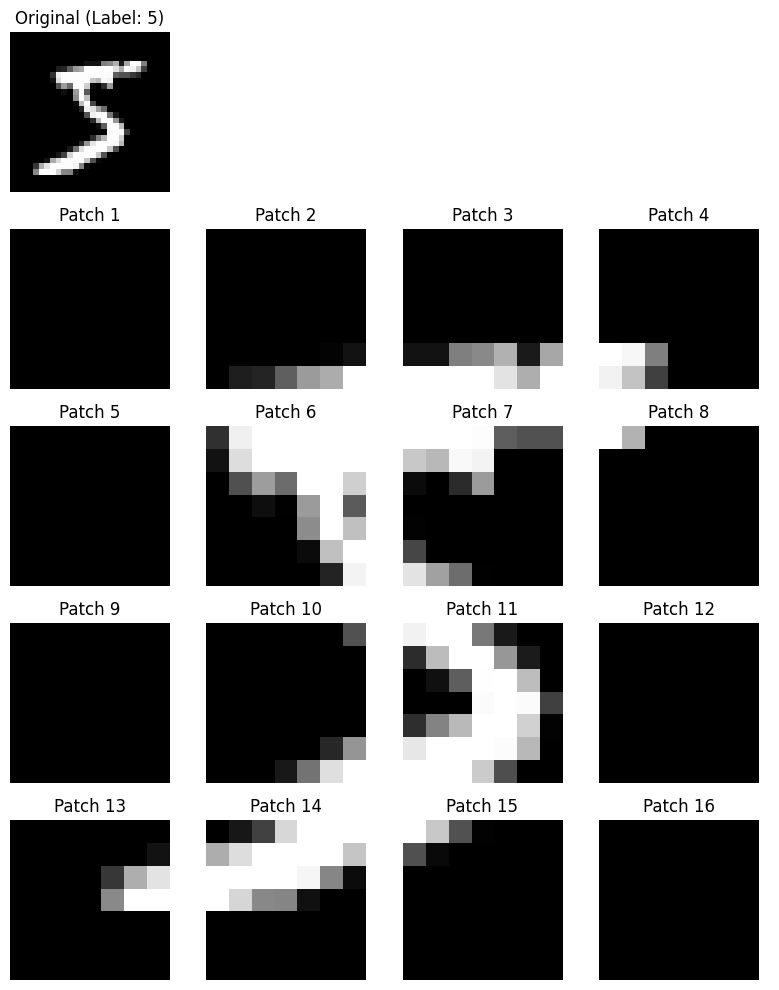


Sequence statistics:
Min value: -0.424
Max value: 2.821


In [94]:
sample_idx = 0
sample_image = X_train[sample_idx].cpu().numpy()
sample_seq = X_train_seq[sample_idx].cpu().numpy()

fig, axes = plt.subplots(5, 4, figsize=(8, 10))
axes[0, 0].imshow(sample_image, cmap='gray')
axes[0, 0].set_title(f"Original (Label: {y_train[sample_idx].item()})")
axes[0, 0].axis('off')

for i in range(1, 4):
    axes[0, i].axis('off')

for i in range(16):
    row = (i // 4) + 1
    col = i % 4
    patch = sample_seq[i].reshape(7, 7)
    axes[row, col].imshow(patch, cmap='gray')
    axes[row, col].set_title(f"Patch {i+1}")
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print(f"\nSequence statistics:")
print(f"Min value: {X_train_seq.min():.3f}")
print(f"Max value: {X_train_seq.max():.3f}")

Designing the model

In [95]:
class PatchRNNModel(torch.nn.Module):
  def __init__(self):
    super(PatchRNNModel, self).__init__()
    self.hidden_size = 64
    self.num_layers = 2
    self.lstm = torch.nn.LSTM(
      input_size=49,
      hidden_size=self.hidden_size,
      num_layers=self.num_layers,
      batch_first=True
    )
    self.fc = torch.nn.Linear(self.hidden_size, 49)
  def forward(self, x, hidden=None):
    lstm_out, hidden = self.lstm(x, hidden)
    batch_size, seq_len, _ = lstm_out.size()
    lstm_out_flat = lstm_out.reshape(-1, self.hidden_size)
    output_flat = self.fc(lstm_out_flat)
    output = output_flat.reshape(batch_size, seq_len, -1)
    return output, hidden
  def generate(self, x_init, num_steps):
    outputs, hidden = self.forward(x_init)
    all_outputs = [outputs]
    current_input = outputs[:, -1:, :]
    # auto-regressive generate future patches
    for _ in range(num_steps):
      pred, hidden = self.forward(current_input, hidden)
      all_outputs.append(pred)
      current_input = pred
    all_outputs = torch.cat(all_outputs, dim=1)
    generated = all_outputs[:, x_init.size(1):, :]
    return generated, all_outputs

In [96]:
model = PatchRNNModel().to(device)
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

In [97]:
def train_rnn(model, train_loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    num_batches = 0
    for batch_sequences in train_loader:
        batch_sequences = batch_sequences.to(device)
        input_seq = batch_sequences[:, :-1, :]
        target_seq = batch_sequences[:, 1:, :]
        
        optimizer.zero_grad()
        predictions, _ = model(input_seq)
        loss = criterion(predictions, target_seq)
        loss.backward()        
        optimizer.step()
        total_loss += loss.item()
        num_batches += 1
    avg_loss = total_loss / num_batches if num_batches > 0 else 0
    return avg_loss
def evaluate_rnn(model, test_loader, criterion):
    model.eval()
    total_loss = 0.0
    num_batches = 0
    with torch.no_grad():
        for batch_sequences in test_loader:
            batch_sequences = batch_sequences.to(device)
            input_seq = batch_sequences[:, :-1, :]
            target_seq = batch_sequences[:, 1:, :]
            predictions, _ = model(input_seq)
            loss = criterion(predictions, target_seq)
            total_loss += loss.item()
            num_batches += 1
    avg_loss = total_loss / num_batches if num_batches > 0 else 0
    return avg_loss

Training Loop

In [98]:
num_epochs = 50
best_val_loss = float('inf')
patience = 5
epochs_no_improve = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    train_loss = train_rnn(model, train_loader, criterion, optimizer)
    train_losses.append(train_loss)
    
    val_loss = evaluate_rnn(model, test_loader, criterion)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'best_patch_rnn_model.pth')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Load best model
model.load_state_dict(torch.load('best_patch_rnn_model.pth'))
print("Best model loaded")

Epoch 1/50, Train Loss: 0.4596, Val Loss: 0.3777
Epoch 2/50, Train Loss: 0.3610, Val Loss: 0.3511
Epoch 3/50, Train Loss: 0.3436, Val Loss: 0.3379
Epoch 4/50, Train Loss: 0.3348, Val Loss: 0.3328
Epoch 5/50, Train Loss: 0.3291, Val Loss: 0.3261
Epoch 6/50, Train Loss: 0.3246, Val Loss: 0.3248
Epoch 7/50, Train Loss: 0.3209, Val Loss: 0.3218
Epoch 8/50, Train Loss: 0.3179, Val Loss: 0.3183
Epoch 9/50, Train Loss: 0.3155, Val Loss: 0.3166
Epoch 10/50, Train Loss: 0.3135, Val Loss: 0.3176
Epoch 11/50, Train Loss: 0.3117, Val Loss: 0.3143
Epoch 12/50, Train Loss: 0.3105, Val Loss: 0.3138
Epoch 13/50, Train Loss: 0.3091, Val Loss: 0.3112
Epoch 14/50, Train Loss: 0.3078, Val Loss: 0.3119
Epoch 15/50, Train Loss: 0.3064, Val Loss: 0.3105
Epoch 16/50, Train Loss: 0.3054, Val Loss: 0.3092
Epoch 17/50, Train Loss: 0.3048, Val Loss: 0.3095
Epoch 18/50, Train Loss: 0.3038, Val Loss: 0.3094
Epoch 19/50, Train Loss: 0.3030, Val Loss: 0.3080
Epoch 20/50, Train Loss: 0.3024, Val Loss: 0.3087
Epoch 21/

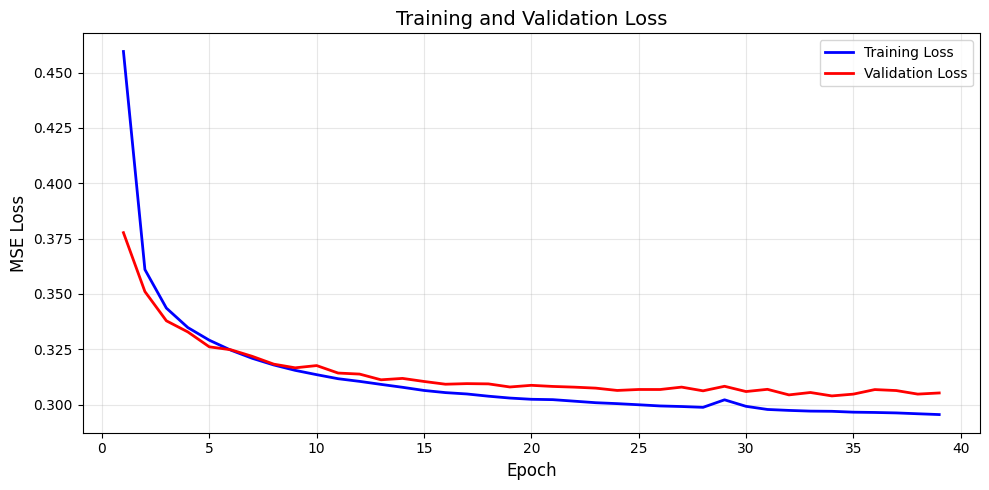


Final Training Loss: 0.295510
Final Validation Loss: 0.305272
Best Validation Loss: 0.303939


In [99]:
# Plot training curves
plt.figure(figsize=(10, 5))
epochs_range = range(1, len(train_losses) + 1)

plt.plot(epochs_range, train_losses, 'b-', label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_losses, 'r-', label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('Training and Validation Loss', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

print(f"\nFinal Training Loss: {train_losses[-1]:.6f}")
print(f"Final Validation Loss: {val_losses[-1]:.6f}")
print(f"Best Validation Loss: {best_val_loss:.6f}")

Generation and Visualization

In [100]:
def gen_bottom_half(model, test_sequences):
    model.eval()
    with torch.no_grad():
        top_half = test_sequences[:, :8, :].to(device)
        predictions, (h, c) = model(top_half)
        
        # Start with the last predicted patch
        current_input = predictions[:, -1:, :]
        generated_patches = [current_input]
        
        for _ in range(7):
            # predict next patch from prediction and hidden states
            pred, (h, c) = model(current_input, (h, c))
            generated_patches.append(pred)
            current_input = pred  
            
        # Concatenate all generated patches
        generated_bottom = torch.cat(generated_patches, dim=1) 
        complete_seq = torch.cat([top_half, generated_bottom], dim=1) 
    return complete_seq.cpu()
  
def patches_to_image(sequence):
    image = torch.zeros((28, 28))
    patch_idx = 0
    for row in range(4):
        for col in range(4):
            patch = sequence[patch_idx].reshape(7, 7)
            image[row*7:(row+1)*7, col*7:(col+1)*7] = patch
            patch_idx += 1
    return image

In [101]:
selected_indices = []
selected_labels = []

for digit in range(10):
    digit_indices = (y_test == digit).nonzero(as_tuple=True)[0]
    
    selected = digit_indices[:10]
    selected_indices.extend(selected)
    selected_labels.extend([digit] * len(selected))
    
selected_indices = torch.tensor(selected_indices)

selected_sequences = X_test_seq[selected_indices]
selected_orginals = X_test[selected_indices]

generated_sequences = gen_bottom_half(model, selected_sequences)

generated_images = []
original_images = []

for i in range(len(selected_indices)):
    gen_img = patches_to_image(generated_sequences[i].cpu())
    generated_images.append(gen_img)
    
    orig_img = selected_orginals[i].cpu()
    original_images.append(orig_img)

generated_images = torch.stack(generated_images)
original_images = torch.stack(original_images)

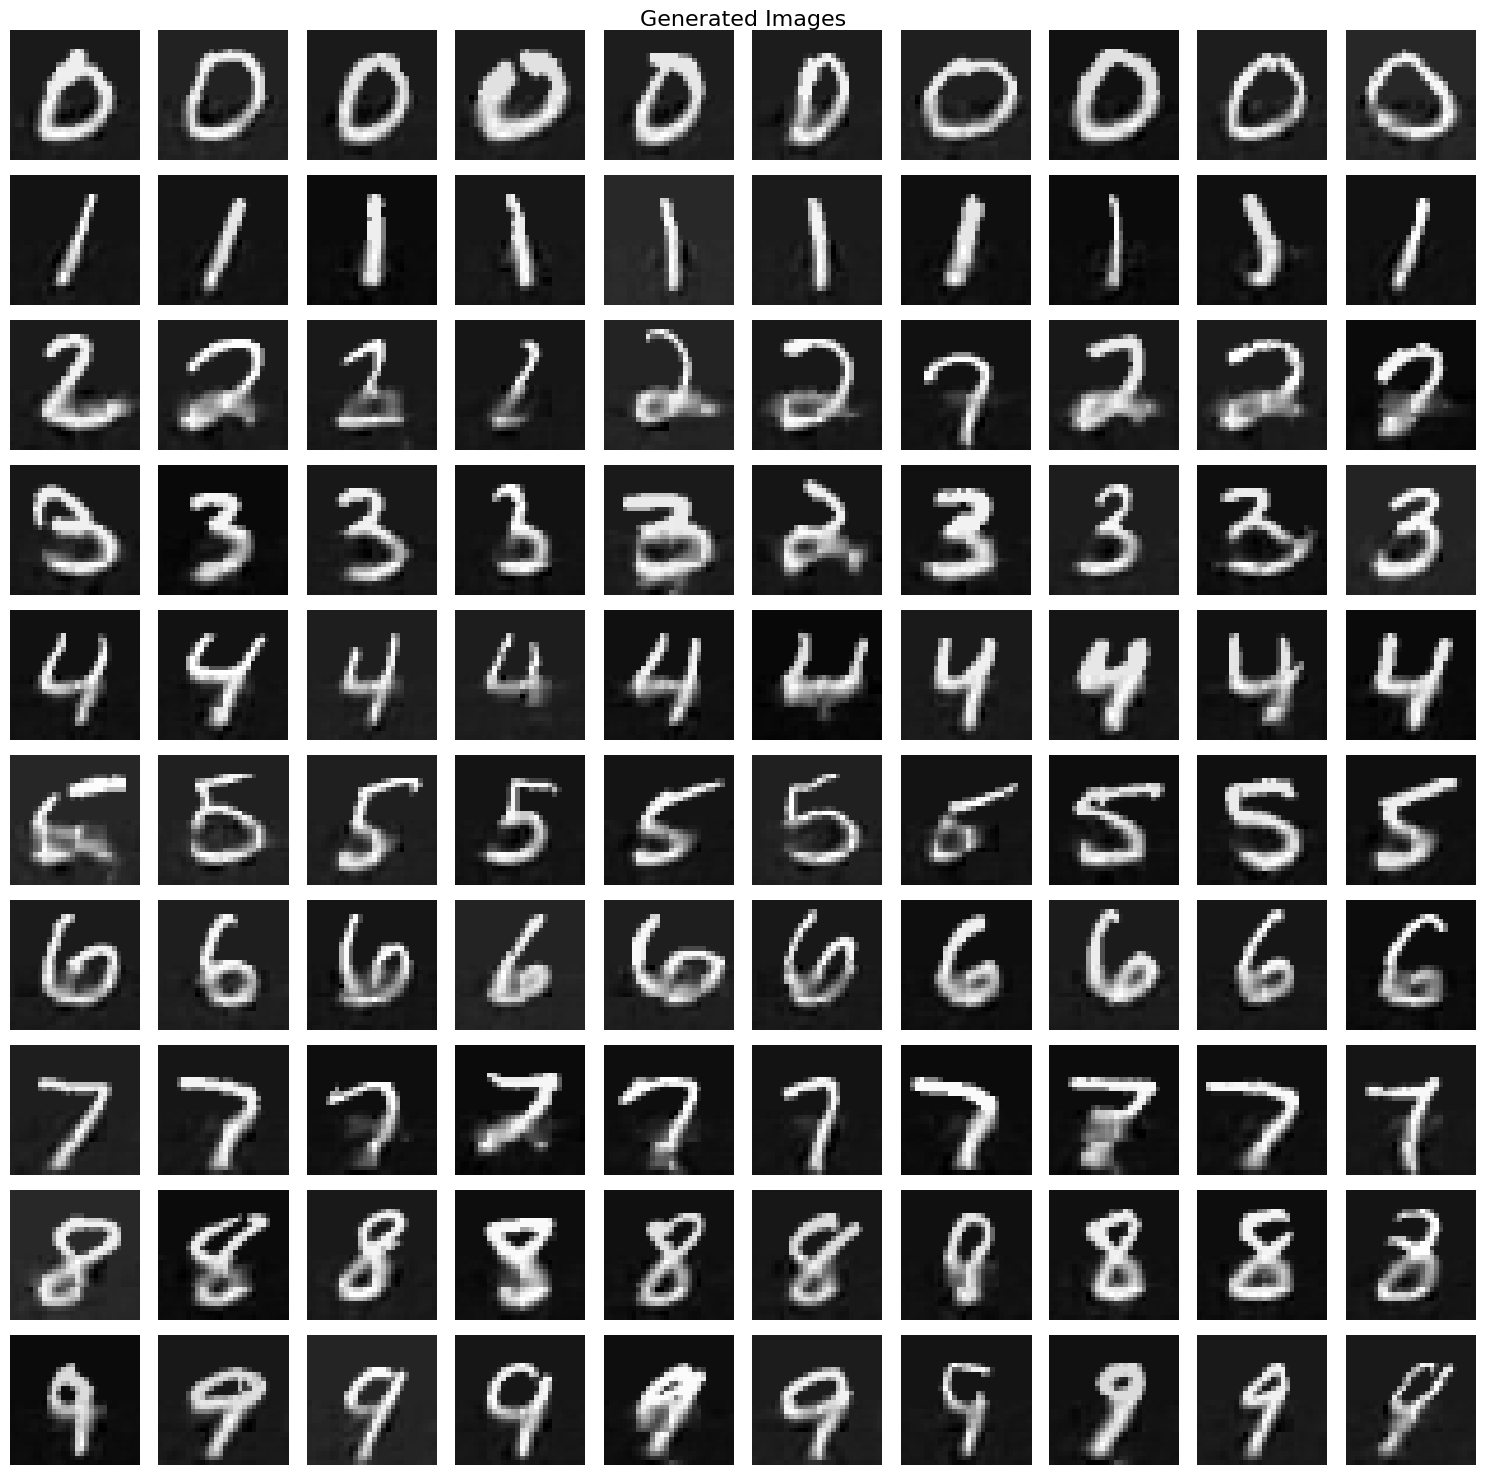

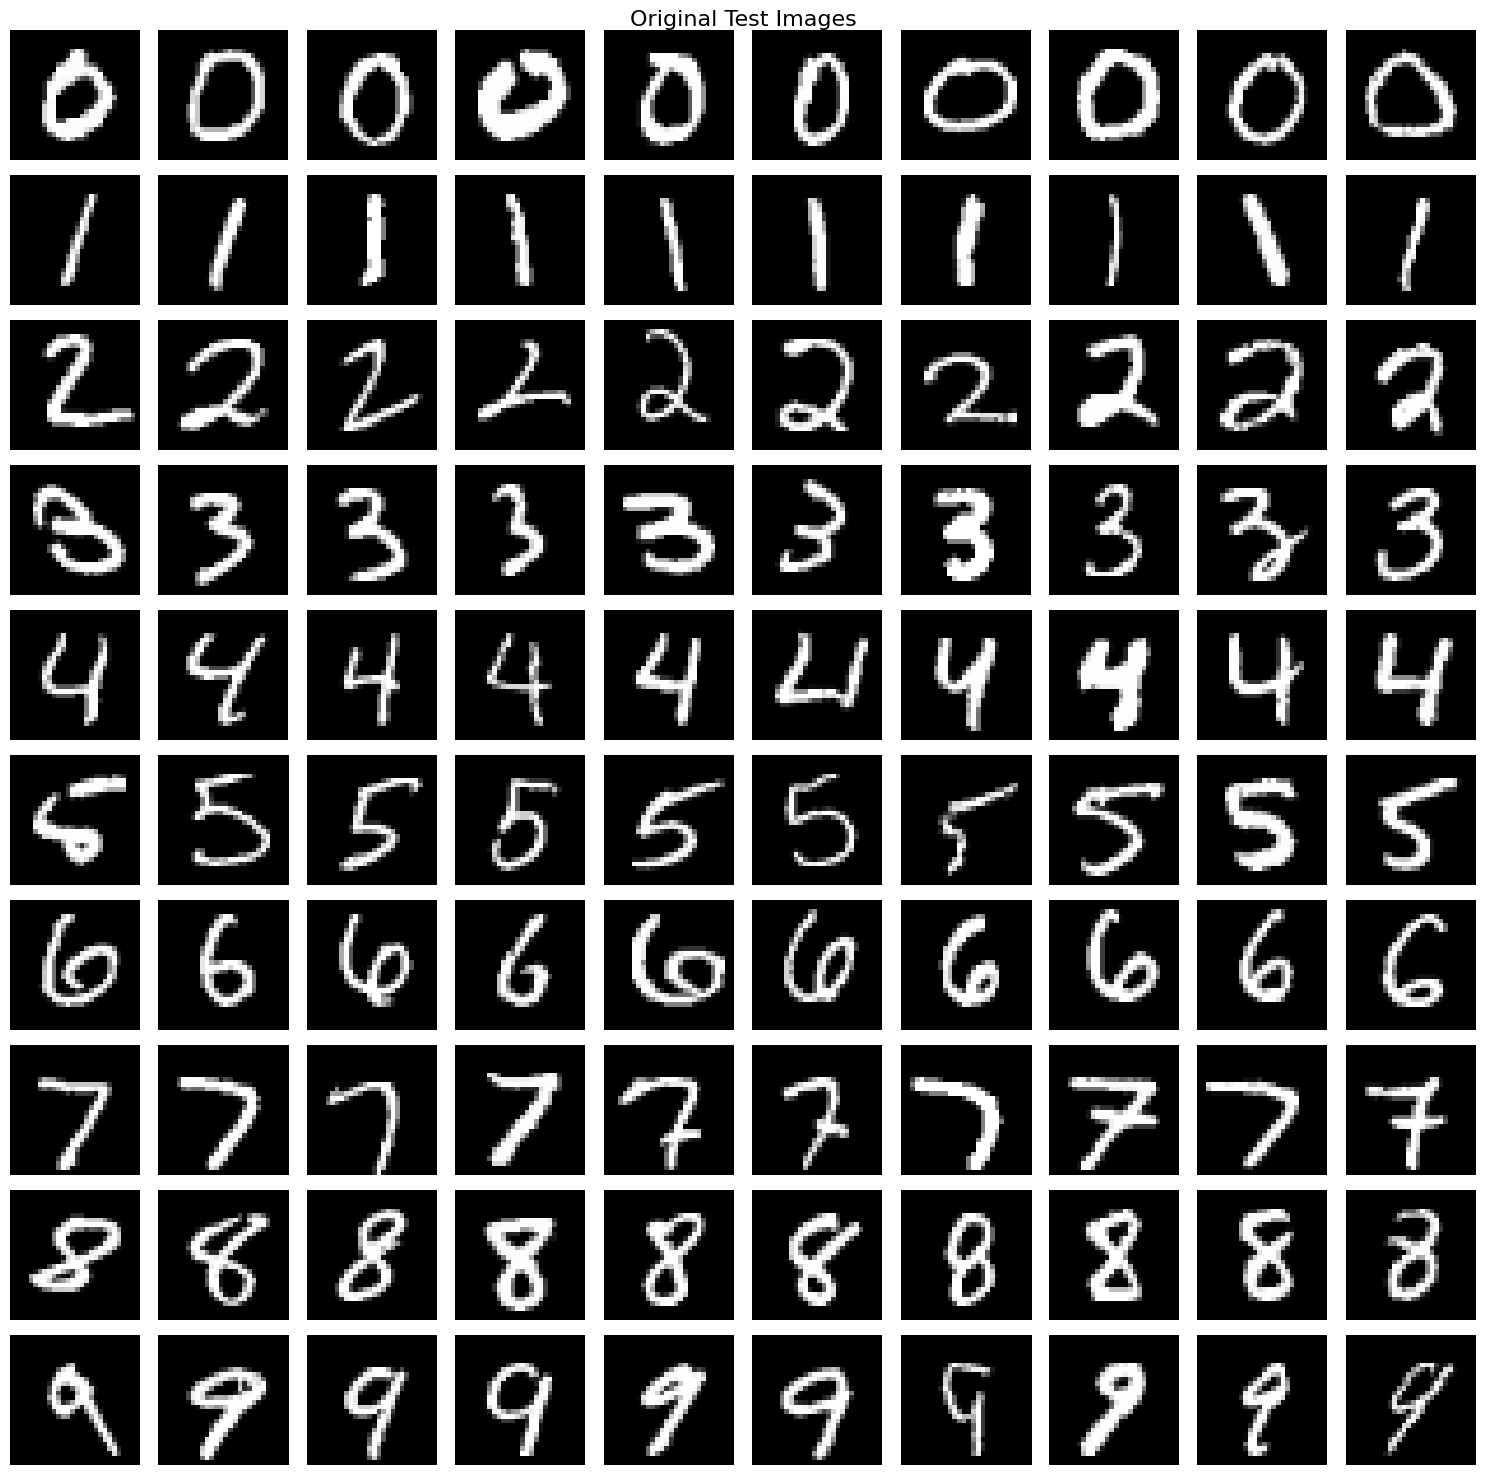

In [102]:
fig, axes = plt.subplots(10, 10, figsize=(15, 15))
fig.suptitle('Generated Images', fontsize=16)

for i in range(100):
    row = i // 10
    col = i % 10
    axes[row, col].imshow(generated_images[i], cmap='gray')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(10, 10, figsize=(15, 15))
fig.suptitle('Original Test Images', fontsize=16)

for i in range(100):
    row = i // 10
    col = i % 10
    axes[row, col].imshow(original_images[i], cmap='gray')
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('original_images_10x10.png', dpi=150, bbox_inches='tight')
plt.show()

# Problem 2: Variational Autoencoders on Poor Sevens

Load Data

In [103]:
import pickle
with open('tr7.pkl', 'rb') as f:
    train_sevens = pickle.load(f)
with open('te7.pkl', 'rb') as f:
    test_sevens = pickle.load(f)
train_sevens = torch.FloatTensor(train_sevens).to(device)
test_sevens = torch.FloatTensor(test_sevens).to(device)

print(f"Train sevens shape: {train_sevens.shape}")
print(f"Test sevens shape: {test_sevens.shape}")

print(f"\nTraining data - Min: {train_sevens.min():.3f}, Max: {train_sevens.max():.3f}")
print(f"Test data - Min: {test_sevens.min():.3f}, Max: {test_sevens.max():.3f}")

Train sevens shape: torch.Size([6265, 28, 28])
Test sevens shape: torch.Size([1028, 28, 28])

Training data - Min: 0.000, Max: 1.000
Test data - Min: 0.000, Max: 1.000


Visualize a few random samples to get a feel for the data

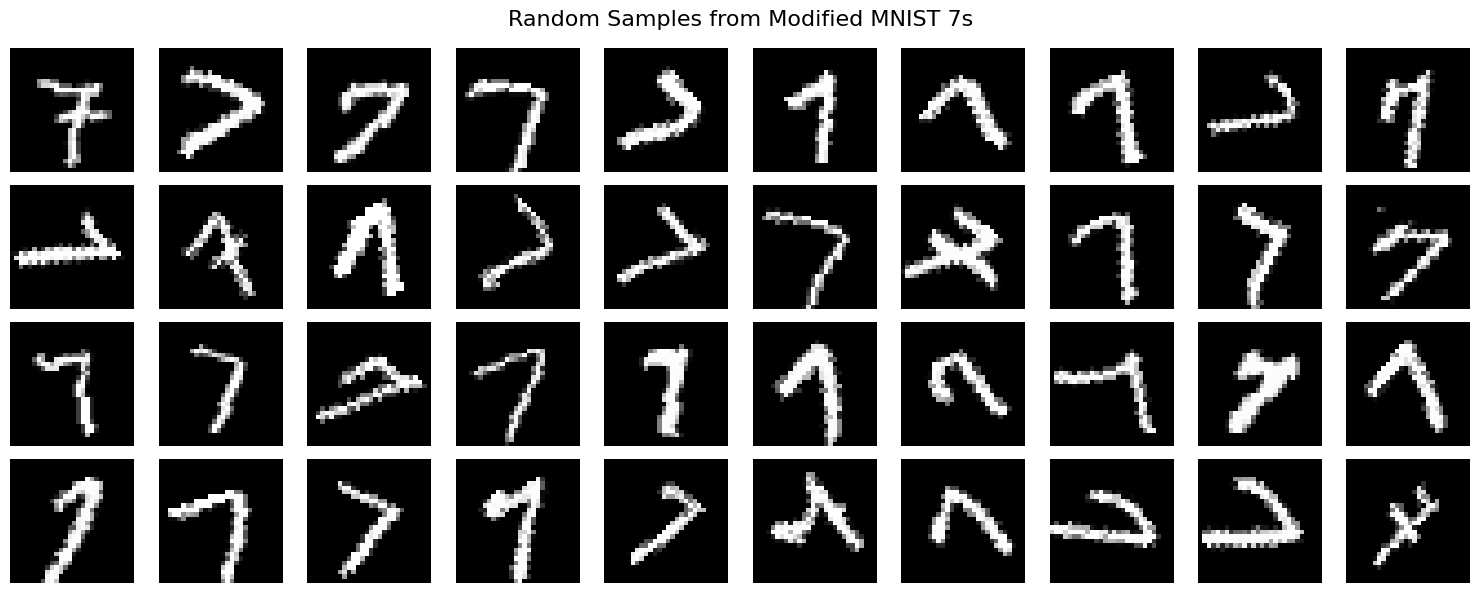

In [104]:
fig, axes = plt.subplots(4, 10, figsize=(15, 6))
fig.suptitle('Random Samples from Modified MNIST 7s', fontsize=16)

random_indices = torch.randperm(len(train_sevens))[:40]

for i in range(40):
    row = i // 10
    col = i % 10
    img = train_sevens[random_indices[i]].cpu().numpy()
    axes[row, col].imshow(img, cmap='gray')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

In [105]:
train_sevens_flat = train_sevens.reshape(-1, 28*28)
test_sevens_flat = test_sevens.reshape(-1, 28*28)

vae_batch_size = 128
train_loader_vae = DataLoader(train_sevens_flat, batch_size=vae_batch_size, shuffle=True)
test_loader_vae = DataLoader(test_sevens_flat, batch_size=vae_batch_size, shuffle=False)

print(f"Number of training batches: {len(train_loader_vae)}")
print(f"Number of test batches: {len(test_loader_vae)}")
print(f"Flattened image shape: {train_sevens_flat.shape}")

Number of training batches: 49
Number of test batches: 9
Flattened image shape: torch.Size([6265, 784])


Architecture Design

In [106]:
class VAE(torch.nn.Module):
    def __init__(self, hidden_dim=400, latent_dim=3):
        super(VAE, self).__init__()
        self.input_dim = 28 * 28
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        
        self.encoder_fc1 = torch.nn.Linear(self.input_dim, self.hidden_dim)
        self.encoder_fc2 = torch.nn.Linear(self.hidden_dim, self.hidden_dim)
        
        self.fc_mu = torch.nn.Linear(self.hidden_dim, self.latent_dim)
        self.fc_logvar = torch.nn.Linear(self.hidden_dim, self.latent_dim)

        self.decoder_fc1 = torch.nn.Linear(self.latent_dim, self.hidden_dim)
        self.decoder_fc2 = torch.nn.Linear(self.hidden_dim, self.hidden_dim)
        self.decoder_fc3 = torch.nn.Linear(self.hidden_dim, self.input_dim)
        
        self.relu = torch.nn.ReLU()
        self.sigmoid = torch.nn.Sigmoid()
    def encode(self, x):
        h = self.relu(self.encoder_fc1(x))
        h = self.relu(self.encoder_fc2(h))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    def decode(self, z):
        h = self.relu(self.decoder_fc1(z))
        h = self.relu(self.decoder_fc2(h))
        recon_x = self.sigmoid(self.decoder_fc3(h))
        return recon_x
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar
    def sample(self, num_samples):
        z = torch.randn(num_samples, self.latent_dim).to(device)
        samples = self.decode(z)
        return samples

In [107]:
latent_dim = 3
vae_model = VAE(hidden_dim=400, latent_dim=latent_dim).to(device)

In [108]:
def vae_loss(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD
optimizer = torch.optim.Adam(vae_model.parameters(), lr=0.001)

Train the model

In [109]:
def train_vae(model, train_loader, optimizer):
    model.train()
    total_loss = 0.0
    num_batches = 0
    for batch_data in train_loader:
        batch_data = batch_data.to(device)
        
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(batch_data)
        loss = vae_loss(recon_batch, batch_data, mu, logvar)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
    avg_loss = total_loss / num_batches if num_batches > 0 else 0
    return avg_loss
def test_vae(model, test_loader):
    model.eval()
    total_loss = 0.0
    num_batches = 0
    with torch.no_grad():
        for batch_data in test_loader:
            batch_data = batch_data.to(device)
            recon_batch, mu, logvar = model(batch_data)
            loss = vae_loss(recon_batch, batch_data, mu, logvar)
            total_loss += loss.item()
            num_batches += 1
    avg_loss = total_loss / num_batches if num_batches > 0 else 0
    return avg_loss

In [110]:
epochs = 50
train_losses_vae = []
test_losses_vae = []

for epoch in range(epochs):
    train_loss = train_vae(vae_model, train_loader_vae, optimizer)
    test_loss = test_vae(vae_model, test_loader_vae)
    
    train_losses_vae.append(train_loss)
    test_losses_vae.append(test_loss)
    
    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")

Epoch 1/50, Train Loss: 30739.3335, Test Loss: 21733.0054
Epoch 2/50, Train Loss: 24203.8543, Test Loss: 20759.0419
Epoch 3/50, Train Loss: 21822.6962, Test Loss: 17451.2195
Epoch 4/50, Train Loss: 19115.1571, Test Loss: 16375.5937
Epoch 5/50, Train Loss: 18414.6532, Test Loss: 15931.9944
Epoch 6/50, Train Loss: 17796.5481, Test Loss: 15164.4812
Epoch 7/50, Train Loss: 17067.6475, Test Loss: 14805.3375
Epoch 8/50, Train Loss: 16714.7196, Test Loss: 14548.4177
Epoch 9/50, Train Loss: 16484.4863, Test Loss: 14480.6240
Epoch 10/50, Train Loss: 16303.2245, Test Loss: 14325.9309
Epoch 11/50, Train Loss: 16194.7269, Test Loss: 14228.9196
Epoch 12/50, Train Loss: 16055.3142, Test Loss: 14135.1876
Epoch 13/50, Train Loss: 15962.5368, Test Loss: 14065.1861
Epoch 14/50, Train Loss: 15861.9734, Test Loss: 13994.3500
Epoch 15/50, Train Loss: 15756.7838, Test Loss: 13999.5795
Epoch 16/50, Train Loss: 15683.5615, Test Loss: 13904.8668
Epoch 17/50, Train Loss: 15612.5398, Test Loss: 13844.8834
Epoch 

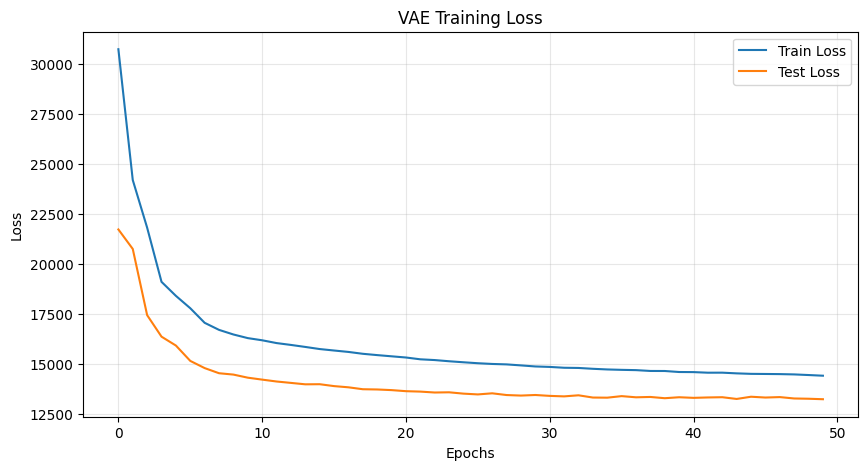

In [111]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses_vae, label='Train Loss')
plt.plot(test_losses_vae, label='Test Loss')
plt.title('VAE Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

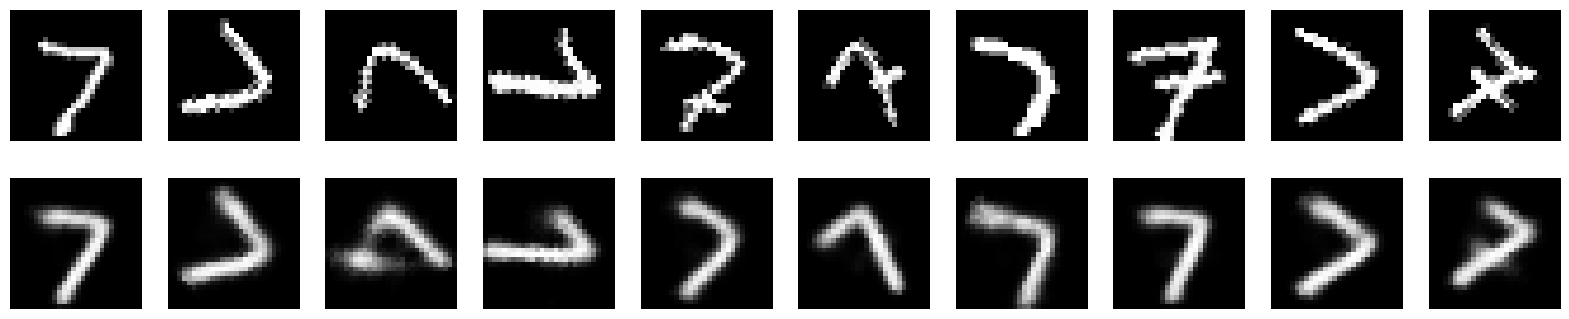

In [112]:
vae_model.eval()
with torch.no_grad():
    data = next(iter(test_loader_vae))
    data = data.to(device)
    
    recon_batch, _, _ = vae_model(data)
    data = data.cpu()
    recon_batch = recon_batch.cpu()
    
    n = 10
    plt.figure(figsize=(20, 4))
    for i in range(n):
        # original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(data[i].reshape(28, 28), cmap='gray')
        ax.axis('off')

        # reconstruction
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(recon_batch[i].reshape(28, 28), cmap='gray')
        ax.axis('off')
    plt.show()

Analyze the Latent Space

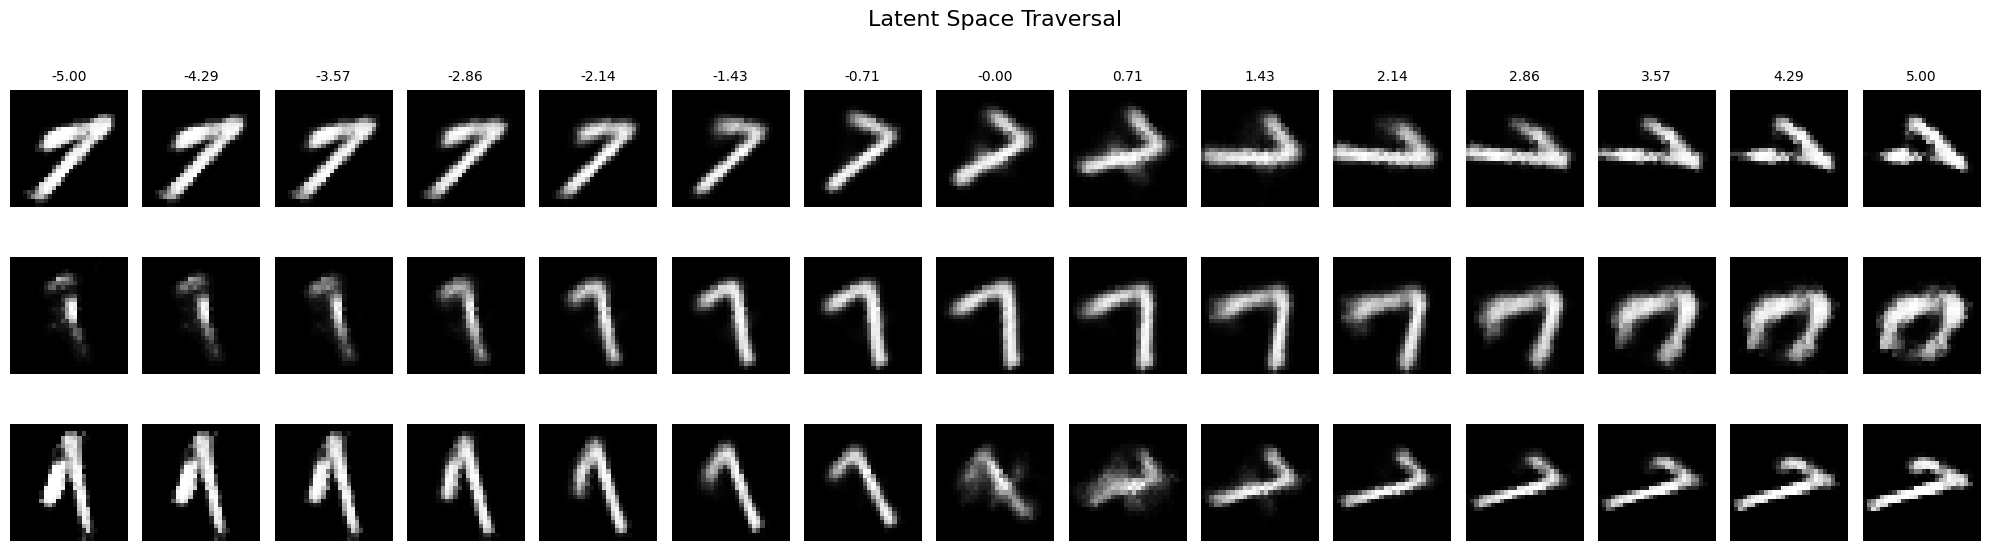

In [113]:
model.eval()

steps = 15
val_range = 5
values = torch.linspace(-val_range, val_range, steps).to(device)

fig, axes = plt.subplots(latent_dim, steps, figsize=(20, 2*latent_dim))
fig.suptitle('Latent Space Traversal', fontsize=16)

for k in range(latent_dim):
    # sample random latent vector
    z = torch.randn(1, latent_dim).to(device)
    z_batch = z.repeat(steps, 1) # repeat for batch processing
    z_batch[:, k] = values # overwrite k-th dimension
    
    with torch.no_grad():
        generated_imgs = vae_model.decode(z_batch).cpu()
    
    for i in range(steps):
        ax = axes[k, i]
        ax.imshow(generated_imgs[i].reshape(28, 28), cmap='gray')
        ax.axis('off')
        if k == 0:
            ax.set_title(f"{values[i]:.2f}", fontsize=10)
    
plt.tight_layout()
plt.show()

After seeing the visualizations of the latent space I'm going to say the first dimension here is the one of interest. The second and third seem to be mostly rotational and thickness based. 

The first dimension however seems to control the noise level of the images. As we move along the first dimension we see the images go from blurry and thick to sharp around 0, and a thin and sparse blob at positive 5. This (and the given images having seemingly some noise injected in based on visual inspection) leads me to believe the added effect is a layer of gaussian noise.

Note: I reran the results and the latent space visualizations changed, but you can still see the noise effect for the second row of the new visuals. The 7 goes from a sparse thin line to a consistent 7 to a thick blurry blob. This is likely the one learning the noise level.

# Problem 3: Conditional GAN

Prepare the data

In [114]:
def get_one_hot(labels):
    num_classes = 10
    one_hot = torch.zeros(labels.size(0), num_classes, device=labels.device)
    one_hot.scatter_(1, labels.unsqueeze(1), 1)
    return one_hot

transform_gan = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5,), (0.5,))
])
mnist_train_gan = torchvision.datasets.MNIST('mnist',
                                         train=True,
                                         download=True,
                                         transform=transform_gan)

batch_size_gan = 100
gan_loader = DataLoader(mnist_train_gan, batch_size=batch_size_gan, shuffle=True, num_workers=4, pin_memory=True)

data_iter = iter(gan_loader)
images, labels = next(data_iter)

Define the model architectures

In [115]:
class Generator(torch.nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.input_dim = 110
        self.output_dim = 28 * 28
        self.model = torch.nn.Sequential(
            torch.nn.Linear(self.input_dim, 200),
            torch.nn.LeakyReLU(),
            torch.nn.Linear(200, 400),
            torch.nn.LeakyReLU(),
            torch.nn.Linear(400, self.output_dim),
            torch.nn.Tanh()
        )
    def forward(self, z, labels):
        x = torch.cat([z, labels], dim=1)
        return self.model(x)

class Discriminator(torch.nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.input_dim = 28 * 28 + 10
        self.model = torch.nn.Sequential(
            torch.nn.Linear(self.input_dim, 400),
            torch.nn.LeakyReLU(),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(400, 200),
            torch.nn.LeakyReLU(),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(200, 100),
            torch.nn.LeakyReLU(),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(100, 1),
            torch.nn.Sigmoid()
        )
    def forward(self, img, labels):
        x = torch.cat([img, labels], dim=1)
        return self.model(x)

In [116]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

Training

In [117]:
num_epochs_gan = 100
criterion_gan = torch.nn.BCELoss()
optimizer_G = torch.optim.Adam(generator.parameters(), lr=0.0002)
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=0.0002)

In [118]:
def train_gan(generator, discriminator, loader, opt_g, opt_d, criterion, epochs):
    generator.train()
    discriminator.train()
    
    d_losses = []
    g_losses = []
    real_scores = []
    fake_scores = []
    
    for epoch in range(epochs):
        epoch_d_loss = 0.0
        epoch_g_loss = 0.0
        epoch_real_score = 0.0
        epoch_fake_score = 0.0
        
        for i, (images, labels) in enumerate(loader):
            batch_size = images.size(0)
            real_images = images.view(batch_size, -1).to(device)
            labels = labels.to(device)
            
            # create ground truths
            valid = torch.ones(batch_size, 1, device=device)
            fake = torch.zeros(batch_size, 1, device=device)
            one_hot_labels = get_one_hot(labels)
            
            #######################
            # Train Discriminator #
            #######################
            opt_d.zero_grad()
            
            # real data
            real_preds = discriminator(real_images, one_hot_labels)
            d_real_loss = criterion(real_preds, valid)
            
            # fake data
            z = torch.randn(batch_size, 100, device=device)
            gen_labels = torch.randint(0, 10, (batch_size,), device=device)
            gen_one_hot = get_one_hot(gen_labels)
            
            # generate fake images
            gen_images = generator(z, gen_one_hot)
            
            fake_preds = discriminator(gen_images.detach(), gen_one_hot)
            d_fake_loss = criterion(fake_preds, fake)
            
            # combine losses and update
            d_loss = d_real_loss + d_fake_loss
            d_loss.backward()
            opt_d.step()
            
            ###################
            # Train Generator #
            ###################
            opt_g.zero_grad()
            
            # generate fake images
            valid_pred = discriminator(gen_images, gen_one_hot)
            g_loss = criterion(valid_pred, valid)
            
            g_loss.backward()
            opt_g.step()
            
            
            # accumulate losses and scores
            epoch_d_loss += d_loss.item()
            epoch_g_loss += g_loss.item()
            epoch_real_score += torch.mean(real_preds).item()
            epoch_fake_score += torch.mean(fake_preds).item()
            
        # average over batches
        num_batches = len(loader)
        d_losses.append(epoch_d_loss / num_batches)
        g_losses.append(epoch_g_loss / num_batches)
        real_scores.append(epoch_real_score / num_batches)
        fake_scores.append(epoch_fake_score / num_batches)
        
        print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {d_losses[-1]:.4f} | G Loss: {g_losses[-1]:.4f} | "
              f"Real Score: {real_scores[-1]:.4f} | Fake Score: {fake_scores[-1]:.4f}")
        
    return d_losses, g_losses, real_scores, fake_scores

d_losses, g_losses, real_scores, fake_scores = train_gan(
    generator, discriminator, gan_loader,
    optimizer_G, optimizer_D,
    criterion_gan, num_epochs_gan
)

Epoch [1/100] | D Loss: 0.4097 | G Loss: 2.7723 | Real Score: 0.8881 | Fake Score: 0.1930
Epoch [2/100] | D Loss: 0.1359 | G Loss: 4.6193 | Real Score: 0.9552 | Fake Score: 0.0490
Epoch [3/100] | D Loss: 0.1240 | G Loss: 4.7174 | Real Score: 0.9632 | Fake Score: 0.0371
Epoch [4/100] | D Loss: 0.1480 | G Loss: 4.7872 | Real Score: 0.9588 | Fake Score: 0.0402
Epoch [5/100] | D Loss: 0.1234 | G Loss: 4.8891 | Real Score: 0.9675 | Fake Score: 0.0323
Epoch [6/100] | D Loss: 0.1326 | G Loss: 4.9692 | Real Score: 0.9654 | Fake Score: 0.0358
Epoch [7/100] | D Loss: 0.2264 | G Loss: 4.1571 | Real Score: 0.9379 | Fake Score: 0.0620
Epoch [8/100] | D Loss: 0.2321 | G Loss: 3.8806 | Real Score: 0.9355 | Fake Score: 0.0648
Epoch [9/100] | D Loss: 0.2719 | G Loss: 3.6462 | Real Score: 0.9235 | Fake Score: 0.0758
Epoch [10/100] | D Loss: 0.2877 | G Loss: 3.8004 | Real Score: 0.9174 | Fake Score: 0.0815
Epoch [11/100] | D Loss: 0.3414 | G Loss: 3.6333 | Real Score: 0.9017 | Fake Score: 0.0994
Epoch [1

Plotting the losses, scores, and generated images

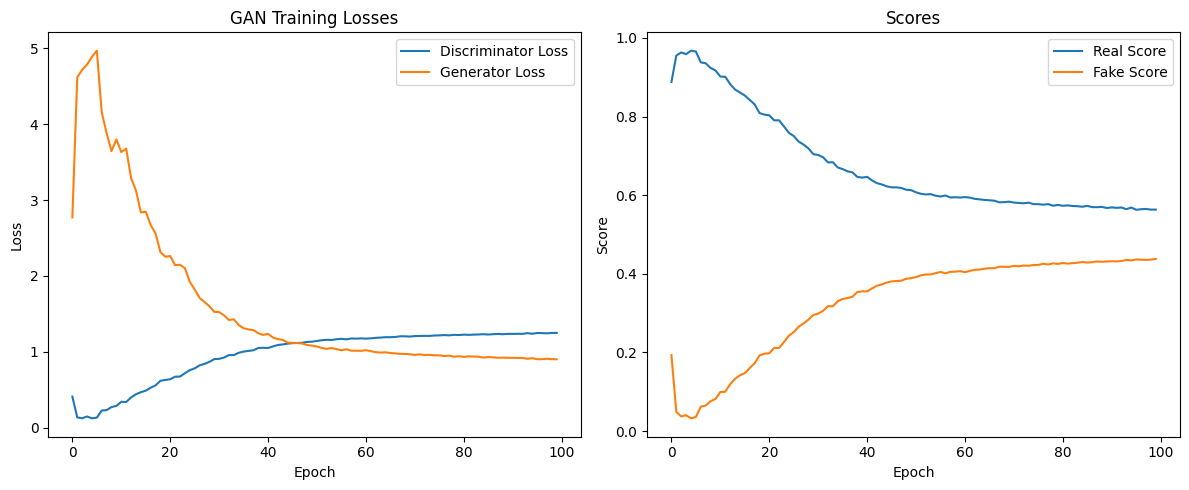

In [119]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(d_losses, label='Discriminator Loss')
plt.plot(g_losses, label='Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('GAN Training Losses')

plt.subplot(1, 2, 2)
plt.plot(real_scores, label='Real Score')
plt.plot(fake_scores, label='Fake Score')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.title('Scores')

plt.tight_layout()
plt.show()

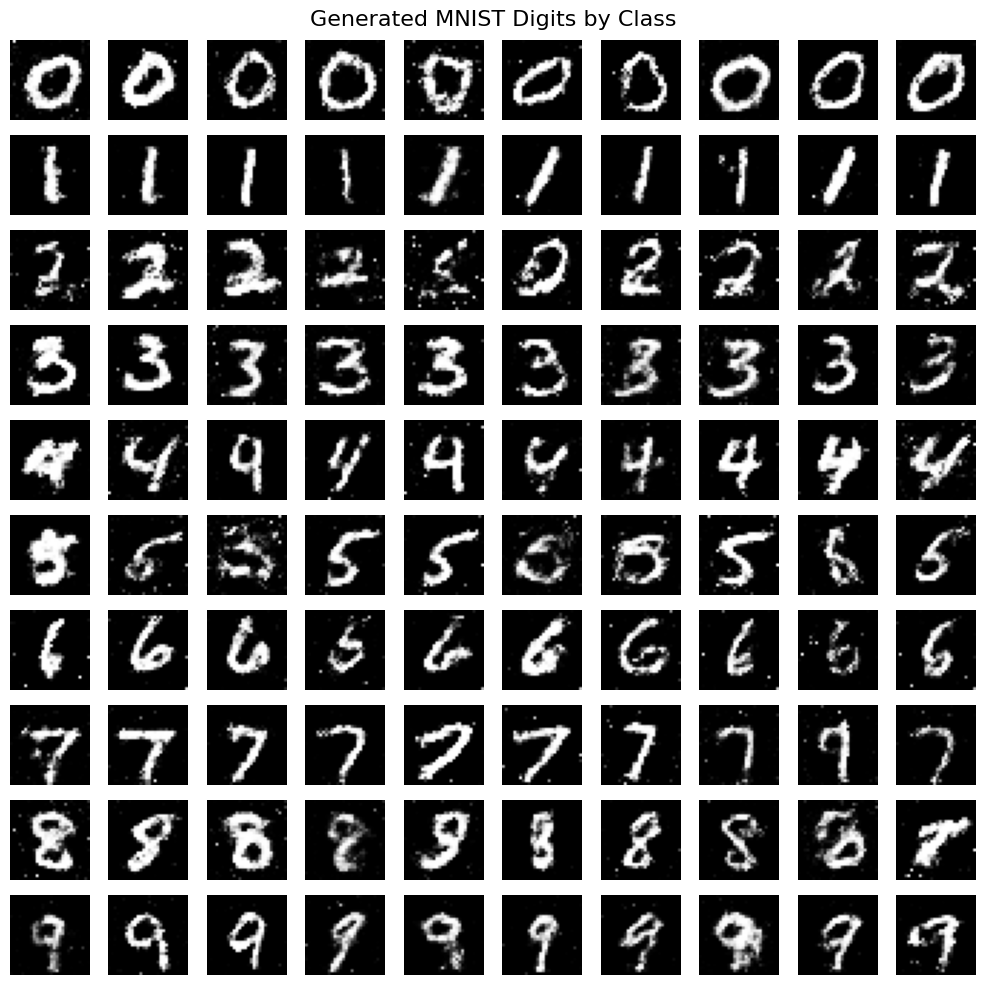

In [120]:
generator.eval()

n_classes = 10
n_examples = 10

labels = torch.LongTensor([i for i in range(n_classes) for _ in range(n_examples)]).to(device)
one_hot_labels = get_one_hot(labels)
z = torch.randn(n_classes * n_examples, 100, device=device)

with torch.no_grad():
    gen_imgs = generator(z, one_hot_labels).cpu()
    gen_imgs = gen_imgs.view(-1, 1, 28, 28)

fig, axes = plt.subplots(n_classes, n_examples, figsize=(n_examples, n_classes))
fig.suptitle('Generated MNIST Digits by Class', fontsize=16)

for i in range(n_classes):
    for j in range(n_examples):
        ax = axes[i, j]
        ax.imshow(gen_imgs[i * n_examples + j].squeeze(), cmap='gray')
        ax.axis('off')
plt.tight_layout()
plt.show()

# Problem 4: Missing Value Imputation Using Conditional GAN

Original Batch: torch.Size([100, 1, 28, 28])
Extracted Patch Batch: torch.Size([100, 100])


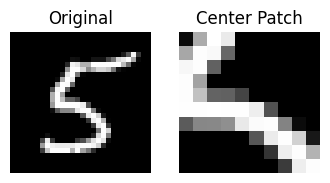

In [121]:
def get_center_patch(images):
    return images[:, :, 9:19, 9:19].reshape(images.size(0), -1)

sample_batch, _ = next(iter(gan_loader))
sample_patch = get_center_patch(sample_batch)
print(f"Original Batch: {sample_batch.shape}")
print(f"Extracted Patch Batch: {sample_patch.shape}")

plt.figure(figsize=(4, 2))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(sample_batch[0].squeeze(), cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Center Patch")
plt.imshow(sample_patch[0].reshape(10, 10), cmap='gray')
plt.axis('off')
plt.show()

In [122]:
class PatchGANGenerator(torch.nn.Module):
    def __init__(self):
        super(PatchGANGenerator, self).__init__()
        self.input_dim = 200 
        self.output_dim = 28 * 28
        self.model = torch.nn.Sequential(
            torch.nn.Linear(self.input_dim, 400),
            torch.nn.LeakyReLU(0.2, inplace=True),
            torch.nn.Linear(400, 400),
            torch.nn.LeakyReLU(0.2, inplace=True),
            torch.nn.Linear(400, self.output_dim),
            torch.nn.Tanh()
        )
    def forward(self, z, condition):
        x = torch.cat([z, condition], dim=1)
        return self.model(x)

class PatchGANDiscriminator(torch.nn.Module):
    def __init__(self):
        super(PatchGANDiscriminator, self).__init__()
        self.input_dim = 28 * 28
        self.model = torch.nn.Sequential(
            torch.nn.Linear(self.input_dim, 400),
            torch.nn.LeakyReLU(0.2, inplace=True),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(400, 200),
            torch.nn.LeakyReLU(0.2, inplace=True),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(200, 1),
            torch.nn.Sigmoid()
        )
    def forward(self, img):
        return self.model(img)

In [123]:
generator_imp = PatchGANGenerator().to(device)
discriminator_imp = PatchGANDiscriminator().to(device)

optimizer_G_imp = torch.optim.Adam(generator_imp.parameters(), lr=0.0002)
optimizer_D_imp = torch.optim.Adam(discriminator_imp.parameters(), lr=0.0002)

criterion_bce = torch.nn.BCELoss()
criterion_mse = torch.nn.MSELoss()

Train the model

In [124]:
def train_patch_gan(generator, discriminator, loader, opt_g, opt_d, criterion_bce, criterion_mse, epochs, lambda_val=10.0):
    generator.train()
    discriminator.train()
    
    d_losses = []
    g_losses = []
    mse_losses = [] 
    real_scores = []
    fake_scores = []
        
    for epoch in range(epochs):
        epoch_d_loss = 0.0
        epoch_g_loss = 0.0
        epoch_mse_loss = 0.0
        epoch_real_score = 0.0
        epoch_fake_score = 0.0
        
        for i, (images, _) in enumerate(loader):
            batch_size = images.size(0)
            
            # real images
            real_images = images.view(batch_size, -1).to(device)
            
            # extract center patches as conditions
            condition = get_center_patch(images).to(device)
            
            # labels
            valid = torch.ones(batch_size, 1, device=device)
            fake = torch.zeros(batch_size, 1, device=device)
            
            #######################
            # Train Discriminator #
            #######################
            opt_d.zero_grad()
            
            # real images
            real_preds = discriminator(real_images)
            d_real_loss = criterion_bce(real_preds, valid)
            
            # fake images
            z = torch.randn(batch_size, 100, device=device)
            gen_images = generator(z, condition)
            
            fake_preds = discriminator(gen_images.detach())
            d_fake_loss = criterion_bce(fake_preds, fake)

            d_loss = d_real_loss + d_fake_loss
            d_loss.backward()
            opt_d.step()
            
            ###################
            # Train Generator #
            ###################
            opt_g.zero_grad()
             
            valid_preds = discriminator(gen_images)
            g_adv_loss = criterion_bce(valid_preds, valid)
            
            # center preservation loss
            gen_images_reshaped = gen_images.view(batch_size, 1, 28, 28)
            gen_center = get_center_patch(gen_images_reshaped)
            g_mse_loss = criterion_mse(gen_center, condition)
            
            g_loss = g_adv_loss + (lambda_val * g_mse_loss)
            
            g_loss.backward()
            opt_g.step()
            
            epoch_d_loss += d_loss.item()
            epoch_g_loss += g_loss.item()
            epoch_mse_loss += g_mse_loss.item()
            epoch_real_score += torch.mean(real_preds).item()
            epoch_fake_score += torch.mean(fake_preds).item()
            
        num_batches = len(loader)
        d_losses.append(epoch_d_loss / num_batches)
        g_losses.append(epoch_g_loss / num_batches)
        mse_losses.append(epoch_mse_loss / num_batches)
        real_scores.append(epoch_real_score / num_batches)
        fake_scores.append(epoch_fake_score / num_batches)
        
        print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {d_losses[-1]:.4f} | "
              f"G Loss: {g_losses[-1]:.4f} | MSE: {mse_losses[-1]:.4f} | "
              f"Real Score: {real_scores[-1]:.4f} | Fake Score: {fake_scores[-1]:.4f}")
              
    return d_losses, g_losses, mse_losses, real_scores, fake_scores

d_losses_imp, g_losses_imp, mse_losses_imp, real_scores_imp, fake_scores_imp = train_patch_gan(
    generator_imp, discriminator_imp, gan_loader,
    optimizer_G_imp, optimizer_D_imp,
    criterion_bce, criterion_mse,
    epochs=100, lambda_val=10.0
)

Epoch [1/100] | D Loss: 0.3963 | G Loss: 6.8634 | MSE: 0.2471 | Real Score: 0.8974 | Fake Score: 0.1752
Epoch [2/100] | D Loss: 0.7301 | G Loss: 3.7074 | MSE: 0.1161 | Real Score: 0.7685 | Fake Score: 0.2578
Epoch [3/100] | D Loss: 0.7428 | G Loss: 3.0145 | MSE: 0.0835 | Real Score: 0.7603 | Fake Score: 0.2582
Epoch [4/100] | D Loss: 0.8217 | G Loss: 2.5879 | MSE: 0.0680 | Real Score: 0.7411 | Fake Score: 0.2745
Epoch [5/100] | D Loss: 0.8641 | G Loss: 2.3617 | MSE: 0.0588 | Real Score: 0.7205 | Fake Score: 0.2890
Epoch [6/100] | D Loss: 0.8947 | G Loss: 2.2236 | MSE: 0.0529 | Real Score: 0.7118 | Fake Score: 0.3000
Epoch [7/100] | D Loss: 0.9715 | G Loss: 1.9891 | MSE: 0.0475 | Real Score: 0.6856 | Fake Score: 0.3262
Epoch [8/100] | D Loss: 0.9898 | G Loss: 1.9111 | MSE: 0.0444 | Real Score: 0.6795 | Fake Score: 0.3333
Epoch [9/100] | D Loss: 1.0082 | G Loss: 1.7968 | MSE: 0.0400 | Real Score: 0.6696 | Fake Score: 0.3409
Epoch [10/100] | D Loss: 1.0411 | G Loss: 1.6962 | MSE: 0.0370 |

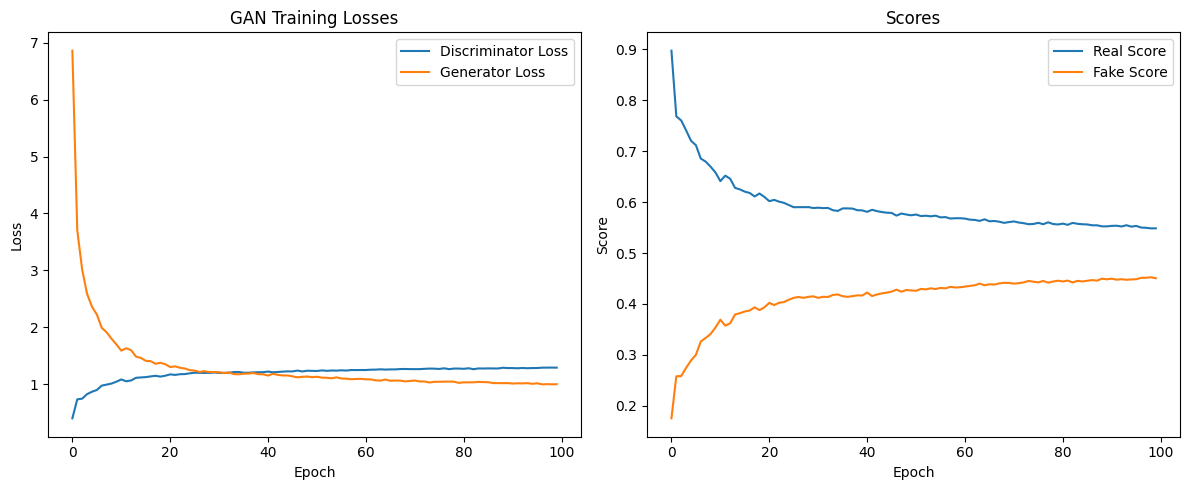

In [125]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(d_losses_imp, label='Discriminator Loss')
plt.plot(g_losses_imp, label='Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('GAN Training Losses')

plt.subplot(1, 2, 2)
plt.plot(real_scores_imp, label='Real Score')
plt.plot(fake_scores_imp, label='Fake Score')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.title('Scores')

plt.tight_layout()
plt.show()

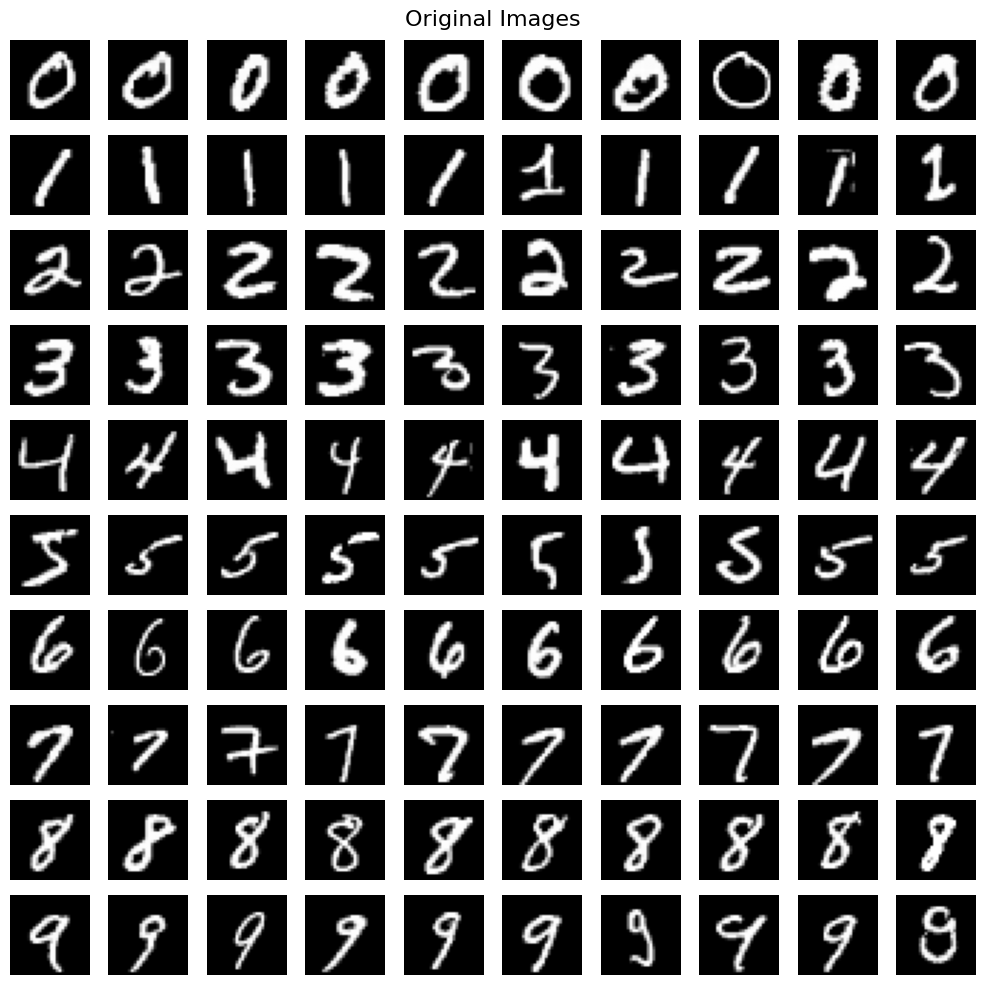

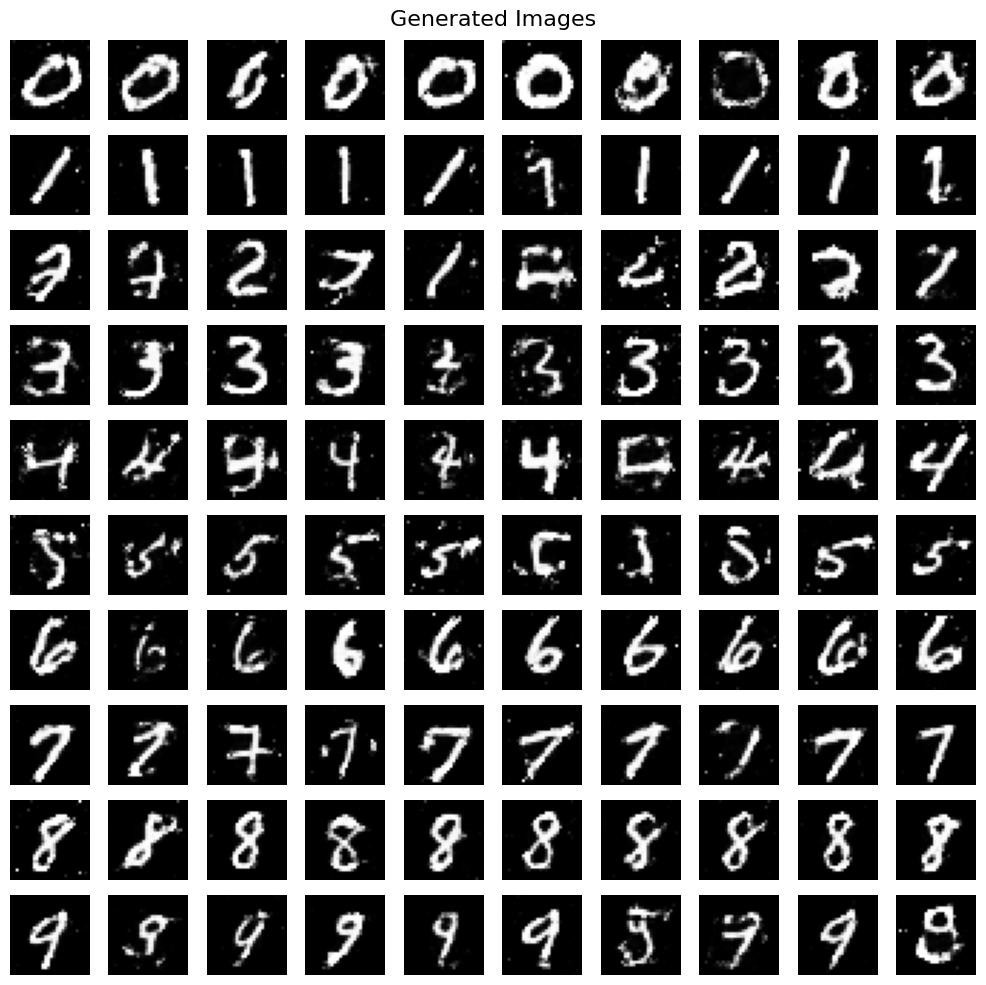

In [126]:
generator_imp.eval()

n_classes = 10
n_examples = 10

samples_by_class = {i: [] for i in range(n_classes)}
samples_collected = {i: 0 for i in range(n_classes)}

for img, label in mnist_train_gan:
    if samples_collected[label] < n_examples:
        samples_by_class[label].append(img)
        samples_collected[label] += 1
    if all(c == n_examples for c in samples_collected.values()):
        break

original_grid = []
generated_grid = []

with torch.no_grad():
    for i in range(n_classes):
        class_imgs = torch.stack(samples_by_class[i])
        original_grid.append(class_imgs)
        
        class_imgs_device = class_imgs.to(device)
        conditions = get_center_patch(class_imgs_device) # Extract center patch
        z = torch.randn(n_examples, 100, device=device)
        
        gen_imgs = generator_imp(z, conditions)
        gen_imgs = gen_imgs.view(n_examples, 1, 28, 28).cpu()
        generated_grid.append(gen_imgs)

original_imgs_flat = torch.cat(original_grid)
generated_imgs_flat = torch.cat(generated_grid)

fig, axes = plt.subplots(n_classes, n_examples, figsize=(n_examples, n_classes))
fig.suptitle('Original Images', fontsize=16)

for i in range(n_classes):
    for j in range(n_examples):
        ax = axes[i, j]
        idx = i * n_examples + j
        ax.imshow(original_imgs_flat[idx].squeeze(), cmap='gray')
        ax.axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(n_classes, n_examples, figsize=(n_examples, n_classes))
fig.suptitle('Generated Images', fontsize=16)

for i in range(n_classes):
    for j in range(n_examples):
        ax = axes[i, j]
        idx = i * n_examples + j
        ax.imshow(generated_imgs_flat[idx].squeeze(), cmap='gray')
        ax.axis('off')

plt.tight_layout()
plt.show()